# Tourism-Hotel VAR Analysis

Time-series assignment: model the relationship between hotel occupancy, room rate,
tourist demand and airfare using a Vector Autoregression (VAR).

**Key methodological decisions made in this notebook (both departures from the class template):**
1. **Levels, not first differences.** ADF and KPSS both say the series are already
   stationary — differencing an already-stationary, mean-reverting series is an
   over-differencing error, not a safe default.
2. **Drop the first 30 observations.** They're a simulation burn-in transient
   (Occupancy starts at 65 and free-falls to roughly -1,000 before settling into
   steady-state oscillation), not a market event — including them would bias every
   estimate that follows.

Ends with an out-of-sample backtest: is the forecast actually better than guessing
"tomorrow = today", or does it just look good in-sample?

## Setup

In [1]:
"""
Tourism-Hotel VAR Pipeline v2 (CORRECTED)
Levels are stationary (ADF strongly rejects unit root; KPSS fails to reject
stationarity) after dropping the simulation burn-in window. VAR is therefore
estimated on LEVELS, not first differences -- differencing would have been
an over-differencing error for a mean-reverting series.
"""
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.api import VAR
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
import warnings
warnings.filterwarnings("ignore")


## Load the data

CSV is expected in the same folder as this notebook. (The original had a hardcoded
`C:\Users\...` path — fixed to a relative path so it runs on any machine, including yours
on a different day.)

In [2]:
df = pd.read_csv("Tourism_Hotel.csv")
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")
df = df.set_index("Date").sort_index().asfreq("D")
df.head(10)


,Occupancy Index,Room Rate Index,Tourist Demand Index,Airfare Index
Date,,,,
2018-01-01,65.000,5200.000,220.000,100.000
2018-01-02,-229.693,4360.155,-72.177,513.667
2018-01-03,-434.528,3815.080,-279.326,750.072
2018-01-04,-578.379,3988.720,-444.862,880.604
2018-01-05,-721.638,3745.294,-578.026,996.620
2018-01-06,-828.776,3100.680,-682.456,1057.022
2018-01-07,-871.124,3264.571,-745.008,1060.830
2018-01-08,-915.158,3230.661,-799.084,1072.644
2018-01-09,-943.738,3355.342,-829.849,1087.221


## Drop the simulation burn-in

First 30 observations are a transient, not real market behaviour — Occupancy starts
at 65 and crashes to ~-1000 before the series settles into steady-state oscillation.
Keeping these rows would bias the stationarity tests and every estimate downstream.

In [3]:
# Drop first 30 obs: simulation burn-in transient (65 -> steady state ~-1005)
BURNIN = 30
y = df.iloc[BURNIN:].copy()
cols = list(y.columns)
short = {"Occupancy Index":"Occ", "Room Rate Index":"Rate",
         "Tourist Demand Index":"Demand", "Airfare Index":"Airfare"}
y = y.rename(columns=short)
cols = list(y.columns)

print("Post burn-in shape:", y.shape)


Post burn-in shape: (2160, 4)


## Stationarity check: levels vs. differencing

This is the decision that matters most in the whole notebook. Run both ADF (null =
unit root) and KPSS (null = stationary) on every series. If ADF rejects and KPSS
fails to reject, the series is stationary in levels — differencing it would be wrong.

(Original notebook printed `lvl` here without ever computing it — fixed below.)

In [4]:
# ---------- stationarity on levels, post burn-in ----------
def adf_kpss(s, name):
    s = s.dropna()
    a_stat, a_p, *_ = adfuller(s, autolag="AIC")
    try:
        k_stat, k_p, *_ = kpss(s, regression="c", nlags="auto")
    except Exception:
        k_stat, k_p = np.nan, np.nan
    return {"series": name, "ADF_stat": a_stat, "ADF_p": a_p, "KPSS_stat": k_stat, "KPSS_p": k_p}

lvl = pd.DataFrame([adf_kpss(y[c], c) for c in cols])
print(lvl)


    series   ADF_stat         ADF_p  KPSS_stat  KPSS_p
0      Occ -12.588060  1.847112e-23   0.134096     0.1
1     Rate -20.794300  0.000000e+00   0.123715     0.1
2   Demand -12.061789  2.459755e-22   0.151393     0.1
3  Airfare -14.365516  9.687442e-27   0.134877     0.1


All four series: ADF rejects the unit-root null, KPSS fails to reject stationarity. Levels it is.

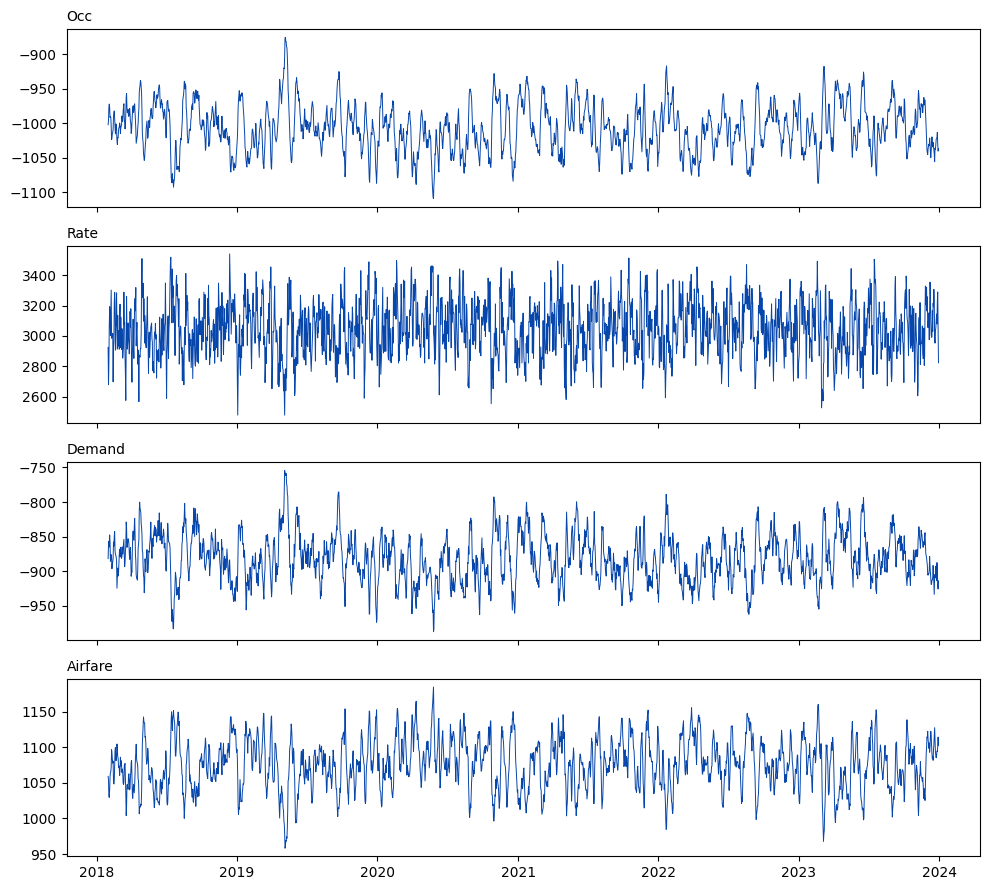

In [5]:
# plot
fig, axes = plt.subplots(len(cols), 1, figsize=(10, 9), sharex=True)
for ax, c in zip(axes, cols):
    ax.plot(y.index, y[c], color="#0746ab", lw=0.7)
    ax.set_title(c, fontsize=10, loc="left")
plt.tight_layout(); plt.show()


## Lag selection and model fit

AIC picks the lag order. More lags fit history better but cost degrees of freedom
and stability — AIC is the standard tradeoff for this.

In [6]:
# ---------- lag selection ----------
model = VAR(y)
lag_sel = model.select_order(maxlags=10)
print(lag_sel.summary())
p = max(lag_sel.aic, 1)
print("Chosen lag (AIC):", p)

results = model.fit(p)
results.summary()


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        26.69       26.71   3.922e+11       26.70
1        19.01      19.06*   1.796e+08       19.03
2        18.99       19.08   1.763e+08      19.02*
3        18.99       19.13   1.764e+08       19.04
4        18.99       19.17   1.767e+08       19.06
5        18.98       19.20   1.755e+08       19.06
6       18.98*       19.25  1.752e+08*       19.08
7        18.99       19.29   1.762e+08       19.10
8        18.99       19.34   1.770e+08       19.12
9        18.99       19.38   1.771e+08       19.14
10       18.99       19.43   1.776e+08       19.15
--------------------------------------------------
Chosen lag (AIC): 6


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 14, Sep, 2026
Time:                     04:04:16
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    19.2492
Nobs:                     2154.00    HQIC:                   19.0821
Log likelihood:          -32573.2    FPE:                1.75961e+08
AIC:                      18.9858    Det(Omega_mle):     1.68023e+08
--------------------------------------------------------------------
Results for equation Occ
                coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------
const             20.842384         3.068624            6.792           0.000
L1.Occ             0.674853         0.021591           31.257           0.000
L1.Rate           -0.059302         0.000508         -116.734           0.

## Residual diagnostics

Before trusting any Granger/IRF/FEVD result, check the residuals aren't hiding
structure the model missed: Ljung-Box for leftover autocorrelation, Jarque-Bera for
non-normality. A model that fails these isn't wrong to use, but its confidence
intervals shouldn't be taken at face value.

In [7]:
# ---------- diagnostics ----------
diag = []
diag.append(f"Stable (statsmodels is_stable): {results.is_stable()}")
resid = results.resid
for c in resid.columns:
    lb = acorr_ljungbox(resid[c], lags=[10], return_df=True)
    diag.append(f"Ljung-Box(10) {c}: stat={lb['lb_stat'].values[0]:.2f} p={lb['lb_pvalue'].values[0]:.4f}")
for c in resid.columns:
    jb, jbp, sk, ku = jarque_bera(resid[c])
    diag.append(f"Jarque-Bera {c}: stat={jb:.2f} p={jbp:.4f} skew={sk:.3f} kurt={ku:.3f}")

print("\n".join(diag))


Stable (statsmodels is_stable): True
Ljung-Box(10) Occ: stat=23.30 p=0.0097
Ljung-Box(10) Rate: stat=4.04 p=0.9454
Ljung-Box(10) Demand: stat=7.87 p=0.6418
Ljung-Box(10) Airfare: stat=9.46 p=0.4895
Jarque-Bera Occ: stat=4.75 p=0.0930 skew=-0.114 kurt=3.025
Jarque-Bera Rate: stat=0.20 p=0.9036 skew=0.001 kurt=2.953
Jarque-Bera Demand: stat=0.08 p=0.9585 skew=-0.014 kurt=2.988
Jarque-Bera Airfare: stat=2.98 p=0.2254 skew=-0.088 kurt=2.951


## Granger causality

Tests predictive precedence, not structural cause — does knowing the past of series X
improve the forecast of series Y beyond what Y's own past already gives you. Read the
result as "leads," not "causes."

In [8]:
# ---------- Granger causality ----------
gc = []
for caused in cols:
    for causing in cols:
        if caused == causing: continue
        t = results.test_causality(caused, [causing], kind="f")
        gc.append((causing, caused, t.test_statistic, t.pvalue, t.pvalue < 0.05))
gc_df = pd.DataFrame(gc, columns=["causing", "caused", "F", "p", "significant_5pct"])
print(gc_df.to_string())


    causing   caused            F              p  significant_5pct
0      Rate      Occ  2311.376833   0.000000e+00              True
1    Demand      Occ   129.696535  1.277757e-157              True
2   Airfare      Occ     6.429510   8.972405e-07              True
3       Occ     Rate     1.246162   2.791042e-01             False
4    Demand     Rate     0.587011   7.410181e-01             False
5   Airfare     Rate     0.943167   4.625162e-01             False
6       Occ   Demand     3.395777   2.393705e-03              True
7      Rate   Demand   167.592858  4.089302e-202              True
8   Airfare   Demand     0.451070   8.446643e-01             False
9       Occ  Airfare     4.648470   1.001977e-04              True
10     Rate  Airfare  5096.637516   0.000000e+00              True
11   Demand  Airfare     5.096381   3.115167e-05              True


## Impulse response functions

If Rate takes an unexpected shock, how does Occupancy respond over the next 24 days,
and how fast does the effect fade? Orthogonalized IRFs — ordering-sensitive, checked
against an alternate ordering in the report (Section 6).

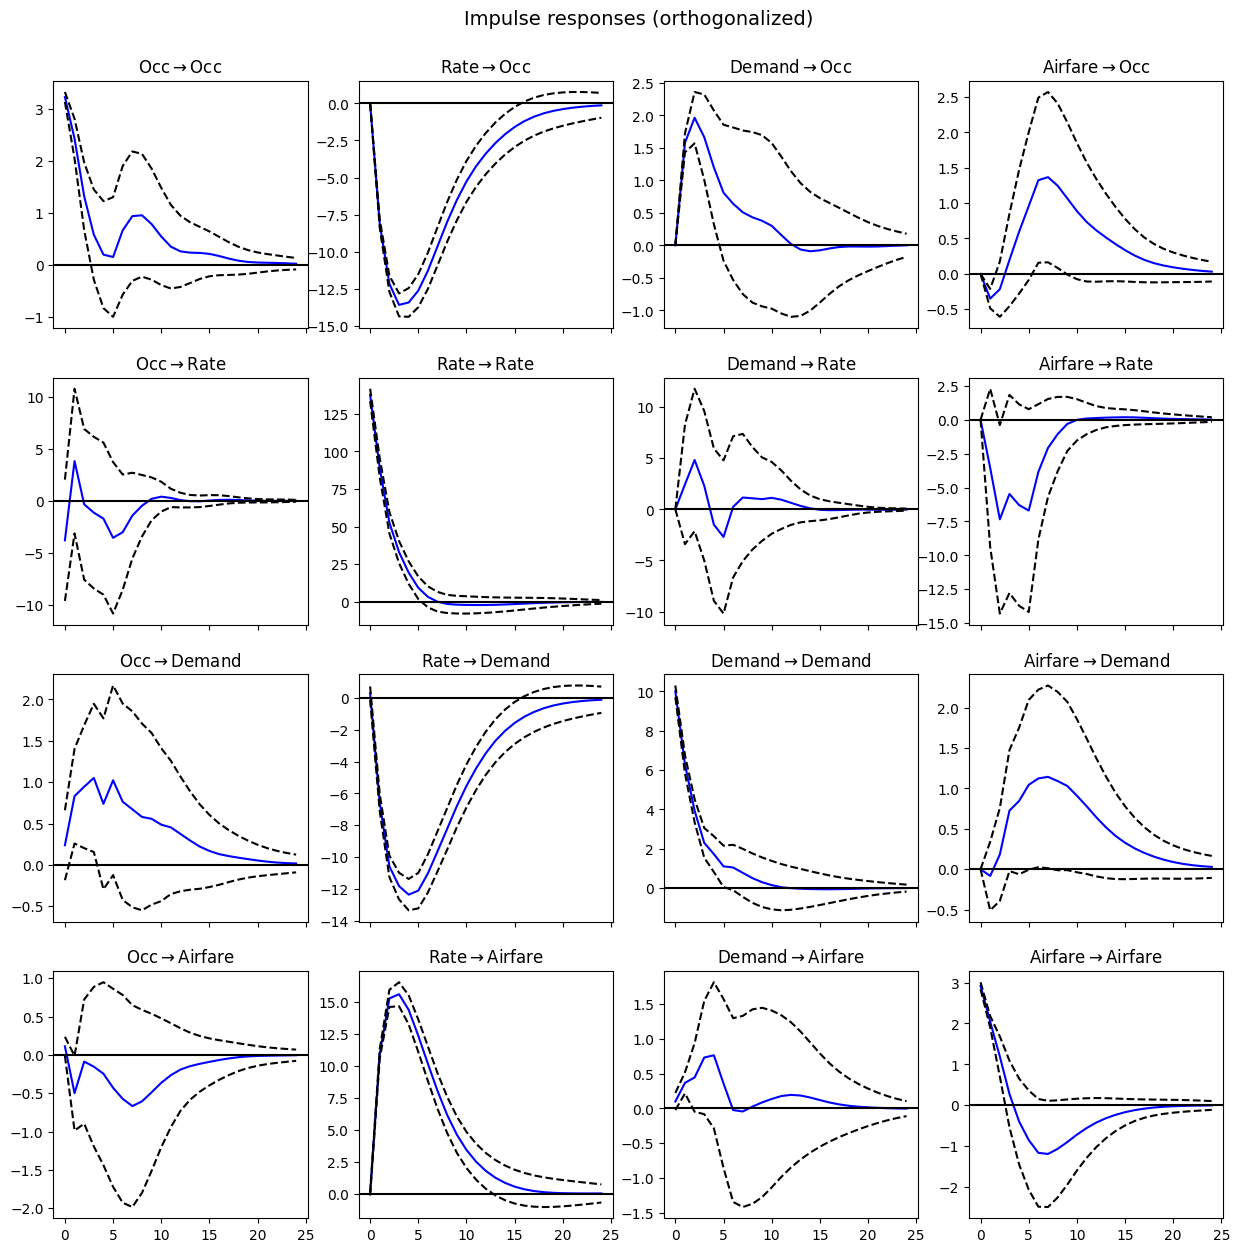

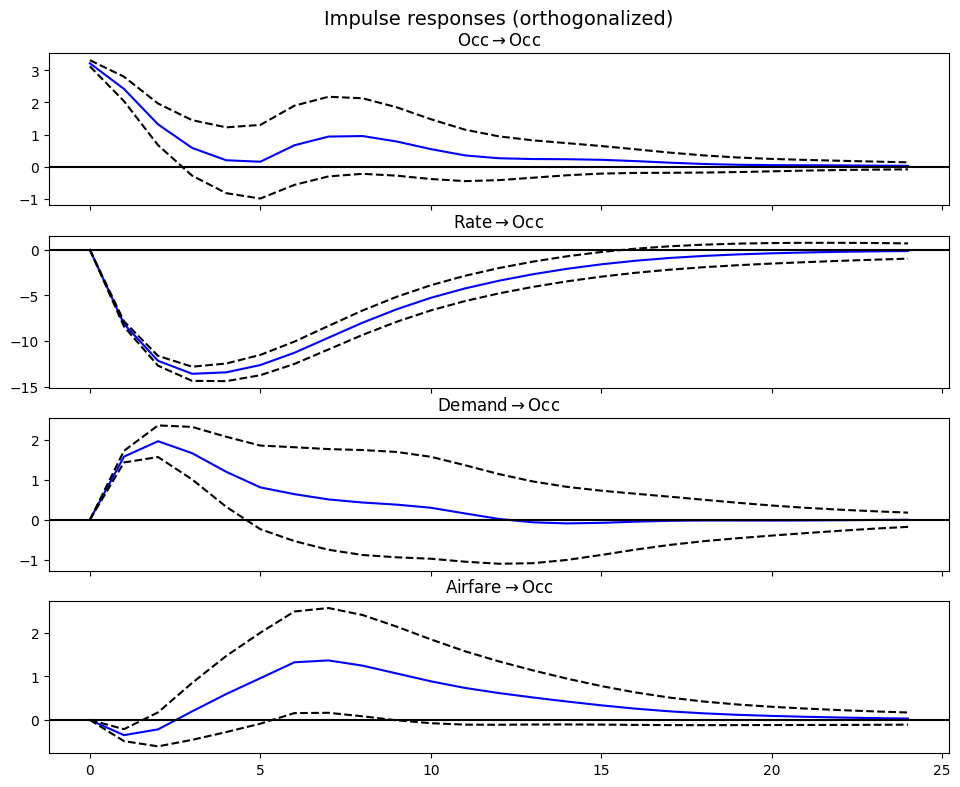

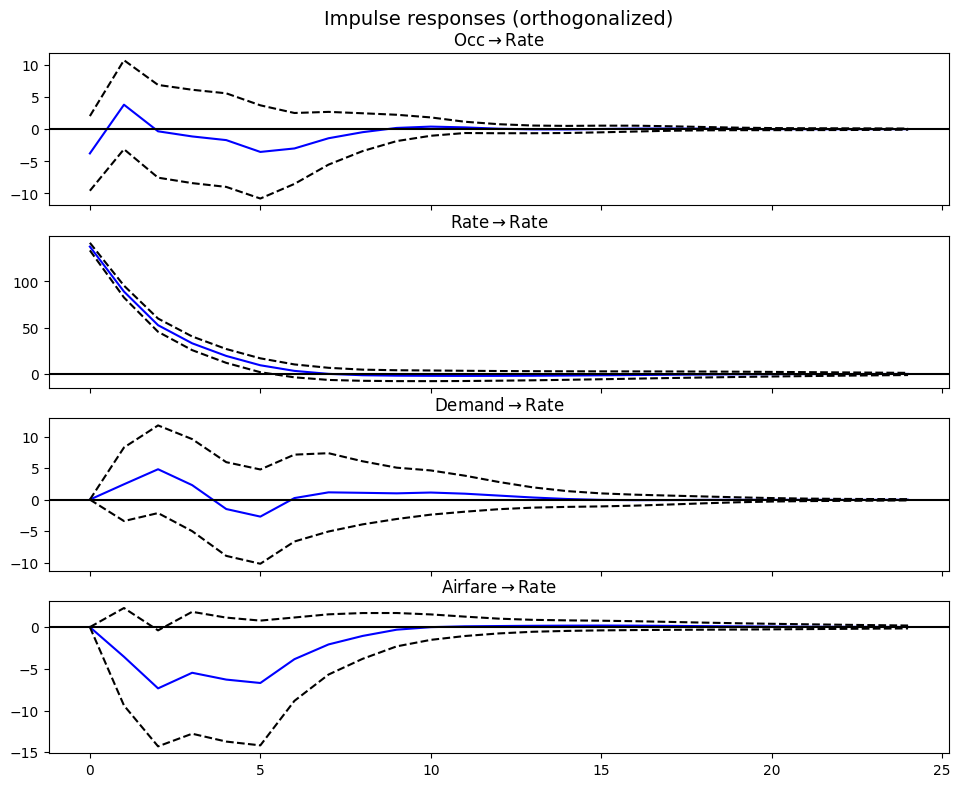

In [9]:
# ---------- IRF ----------
irf = results.irf(24)
fig = irf.plot(orth=True, signif=0.05)
fig.set_size_inches(13, 13)
plt.show()

fig2 = irf.plot(response="Occ", orth=True, signif=0.05)
fig2.set_size_inches(10, 8)
plt.show()

fig3 = irf.plot(response="Rate", orth=True, signif=0.05)
fig3.set_size_inches(10, 8)
plt.show()


## Forecast error variance decomposition (FEVD)

Of Occupancy's own forecast uncertainty at each horizon, how much is explained by
Occupancy's own past vs. Rate, Demand, Airfare? This is where the "Rate explains ~96%
of Occupancy's variance" headline number comes from.

FEVD for Occ
           Occ      Rate    Demand   Airfare
0     1.000000  0.000000  0.000000  0.000000
1     0.192170  0.776997  0.029388  0.001444
2     0.075722  0.896897  0.026669  0.000711
3     0.043166  0.934908  0.021437  0.000489
4     0.030309  0.951374  0.017390  0.000926
5     0.023994  0.959474  0.014604  0.001928
6     0.021020  0.962425  0.012952  0.003603
7     0.019880  0.963016  0.011967  0.005137
8     0.019493  0.962831  0.011394  0.006283
9     0.019265  0.962607  0.011066  0.007062
10    0.019037  0.962521  0.010865  0.007577
11    0.018835  0.962530  0.010711  0.007924
12    0.018700  0.962529  0.010602  0.008170
13    0.018627  0.962492  0.010537  0.008344
14    0.018599  0.962435  0.010503  0.008463
15    0.018594  0.962383  0.010484  0.008539
16    0.018594  0.962349  0.010472  0.008585
17    0.018593  0.962330  0.010465  0.008612
18    0.018591  0.962321  0.010461  0.008627
19    0.018589  0.962315  0.010459  0.008637
20    0.018588  0.962311  0.010458  0.0086

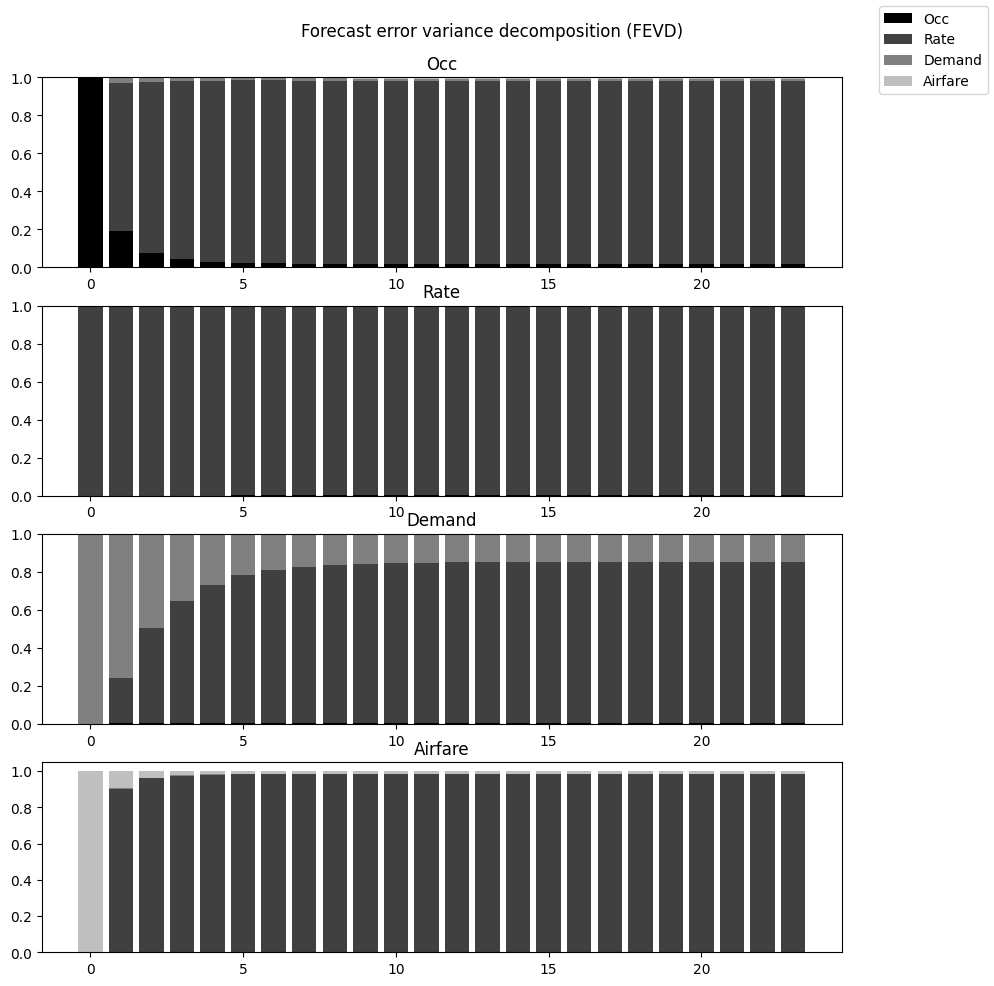

              Occ      Rate    Demand   Airfare
horizon                                        
1        1.000000  0.000000  0.000000  0.000000
2        0.192170  0.776997  0.029388  0.001444
3        0.075722  0.896897  0.026669  0.000711
4        0.043166  0.934908  0.021437  0.000489
5        0.030309  0.951374  0.017390  0.000926
6        0.023994  0.959474  0.014604  0.001928
7        0.021020  0.962425  0.012952  0.003603
8        0.019880  0.963016  0.011967  0.005137
9        0.019493  0.962831  0.011394  0.006283
10       0.019265  0.962607  0.011066  0.007062
11       0.019037  0.962521  0.010865  0.007577
12       0.018835  0.962530  0.010711  0.007924
13       0.018700  0.962529  0.010602  0.008170
14       0.018627  0.962492  0.010537  0.008344
15       0.018599  0.962435  0.010503  0.008463
16       0.018594  0.962383  0.010484  0.008539
17       0.018594  0.962349  0.010472  0.008585
18       0.018593  0.962330  0.010465  0.008612
19       0.018591  0.962321  0.010461  0

In [10]:
# ---------- FEVD ----------
fevd = results.fevd(24)
fevd.summary()
fig4 = fevd.plot(); fig4.set_size_inches(10, 10)
plt.show()

occ_idx = cols.index("Occ")
fevd_occ = pd.DataFrame(fevd.decomp[occ_idx], columns=cols)
fevd_occ.index = range(1, len(fevd_occ)+1)
fevd_occ.index.name = "horizon"
print(fevd_occ)

rate_idx = cols.index("Rate")
fevd_rate = pd.DataFrame(fevd.decomp[rate_idx], columns=cols)
fevd_rate.index = range(1, len(fevd_rate)+1)
fevd_rate.index.name = "horizon"
print(fevd_rate)


## 10-day forecast (full-sample model)

This is a point forecast fit on everything, including the days it's forecasting —
it shows what the model expects, not whether the model is any good. That question is
answered in the backtest section below, not here.

In [11]:
# ---------- Forecast ----------
lag_order = results.k_ar
fc = results.forecast(y.values[-lag_order:], steps=10)
fc_df = pd.DataFrame(fc, columns=cols)
print(fc_df)

print("DONE v2")


           Occ         Rate      Demand      Airfare
0 -1020.758185  2895.839047 -896.949194  1077.890332
1 -1009.331629  2959.264618 -885.543845  1065.633868
2 -1002.364562  2994.005876 -881.265600  1062.123229
3  -999.655665  3010.617621 -876.610343  1061.984088
4  -997.935805  3024.782426 -873.948750  1063.036686
5  -997.740381  3036.429154 -872.912077  1064.650098
6  -998.687204  3042.541820 -872.888223  1066.685363
7  -999.879701  3044.570121 -873.236954  1068.705361
8 -1000.864122  3045.515044 -874.177409  1070.409220
9 -1001.706140  3046.695439 -875.128059  1071.740014
DONE v2


Same forecast with 95% confidence intervals, plotted against recent history.

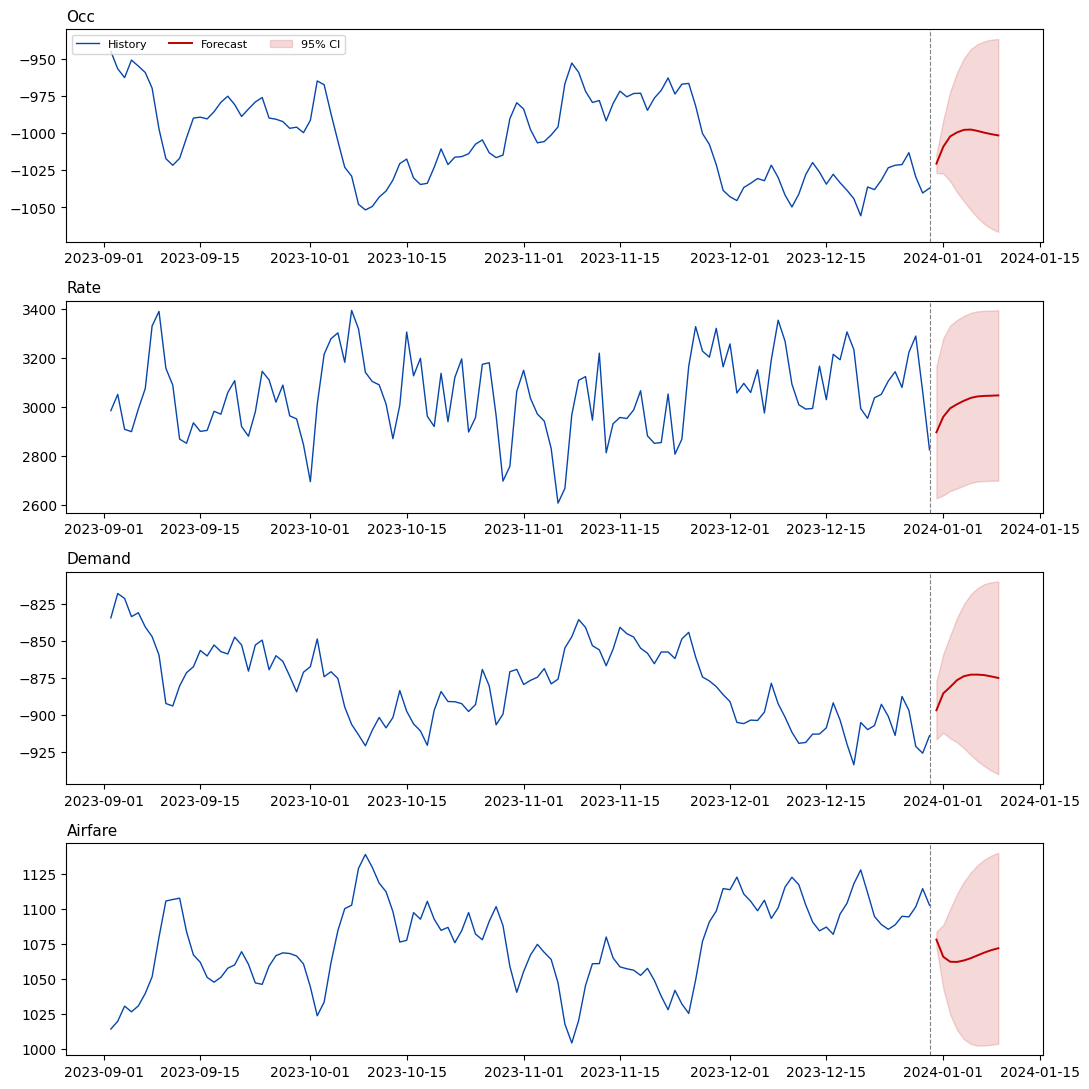

In [12]:
# ---------- Forecast plot with 95% CI ----------
STEPS = 10
point, lower, upper = results.forecast_interval(y.values[-lag_order:], steps=STEPS, alpha=0.05)
future_dates = pd.date_range(y.index[-1] + pd.Timedelta(days=1), periods=STEPS, freq="D")

HIST_DAYS = 120
hist = y.iloc[-HIST_DAYS:]

fig, axes = plt.subplots(len(cols), 1, figsize=(11, 11), sharex=False)
for i, (ax, c) in enumerate(zip(axes, cols)):
    ax.plot(hist.index, hist[c], color="#0746ab", lw=1.0, label="History")
    ax.plot(future_dates, point[:, i], color="#C00000", lw=1.4, label="Forecast")
    ax.fill_between(future_dates, lower[:, i], upper[:, i],
                     color="#C00000", alpha=0.15, label="95% CI")
    ax.axvline(y.index[-1], color="grey", ls="--", lw=0.8)
    ax.set_title(c, fontsize=11, loc="left")
    if i == 0:
        ax.legend(loc="upper left", fontsize=8, ncol=3)

plt.tight_layout()
plt.show()


## Out-of-sample backtest — does it actually forecast?

Everything above fits the full sample, including the days being forecast — that's not
evidence the model works. Here: hold out the last 10 days, re-fit VAR on the training
data only (lag re-selected on train, not the full sample), forecast forward, and check
against actuals *and* against a naive "tomorrow = today" benchmark. Matches the backtest
in `VAR_pipeline.py` and Section 11 of the report — same numbers, so all three deliverables
tell the same story.

In [13]:
# ---------- Backtest: hold out last 10 days, compare to naive benchmark ----------
HOLDOUT = 10
train = y.iloc[:-HOLDOUT]
test = y.iloc[-HOLDOUT:]

bt_model = VAR(train)
bt_lag_sel = bt_model.select_order(maxlags=10)
bt_p = max(bt_lag_sel.aic, 1)
print("Backtest lag (chosen on TRAIN only):", bt_p)

bt_results = bt_model.fit(bt_p)
bt_lag_order = bt_results.k_ar
bt_fc = bt_results.forecast(train.values[-bt_lag_order:], steps=HOLDOUT)
bt_fc_df = pd.DataFrame(bt_fc, columns=cols, index=test.index)

naive = pd.DataFrame(np.tile(train.iloc[-1].values, (HOLDOUT, 1)), columns=cols, index=test.index)

def metrics(actual, pred, name):
    err = actual - pred
    rmse = np.sqrt((err**2).mean())
    mae = err.abs().mean()
    mape = (err.abs() / actual.abs()).mean() * 100
    return pd.Series({"RMSE": rmse, "MAE": mae, "MAPE_%": mape}, name=name)

rows = []
for c in cols:
    rows.append(metrics(test[c], bt_fc_df[c], f"{c} (VAR)"))
    rows.append(metrics(test[c], naive[c], f"{c} (naive)"))
backtest_report = pd.DataFrame(rows)
print(backtest_report)


Backtest lag (chosen on TRAIN only): 6
                       RMSE         MAE    MAPE_%
Occ (VAR)         16.384272   12.610841  1.220350
Occ (naive)       27.875806   26.525100  2.583832
Rate (VAR)       132.730717  103.630787  3.349045
Rate (naive)     149.551246  125.629500  4.032567
Demand (VAR)      23.347379   18.069171  1.973945
Demand (naive)    11.895503   10.348100  1.139485
Airfare (VAR)     19.180185   14.273810  1.295159
Airfare (naive)   31.500340   30.122200  2.752001


In [14]:
# ---------- Does the VAR beat the naive benchmark? ----------
skill = pd.DataFrame({
    "VAR_RMSE": [metrics(test[c], bt_fc_df[c], "")["RMSE"] for c in cols],
    "Naive_RMSE": [metrics(test[c], naive[c], "")["RMSE"] for c in cols],
}, index=cols)
skill["VAR_beats_naive"] = skill["VAR_RMSE"] < skill["Naive_RMSE"]
skill["improvement_%"] = (1 - skill["VAR_RMSE"] / skill["Naive_RMSE"]) * 100
print(skill)


           VAR_RMSE  Naive_RMSE  VAR_beats_naive  improvement_%
Occ       16.384272   27.875806             True      41.224040
Rate     132.730717  149.551246             True      11.247335
Demand    23.347379   11.895503            False     -96.270635
Airfare   19.180185   31.500340             True      39.111181


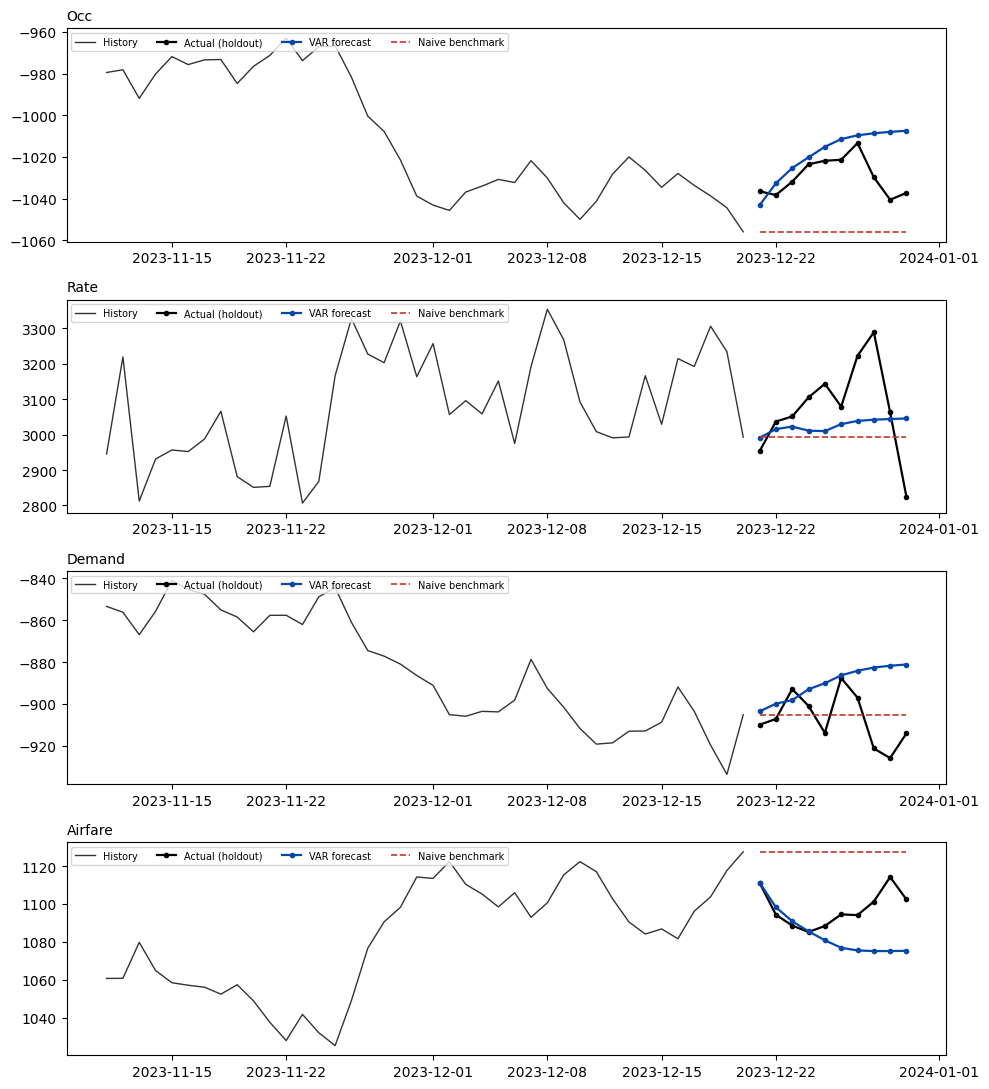

In [15]:
# ---------- Backtest plot: actual vs VAR forecast vs naive ----------
fig5, axes = plt.subplots(len(cols), 1, figsize=(10, 11), sharex=False)
hist40 = train.iloc[-40:]
for ax, c in zip(axes, cols):
    ax.plot(hist40.index, hist40[c], color="#333333", lw=1.0, label="History")
    ax.plot(test.index, test[c], color="#000000", lw=1.6, marker="o", ms=3, label="Actual (holdout)")
    ax.plot(test.index, bt_fc_df[c], color="#0746ab", lw=1.6, marker="o", ms=3, label="VAR forecast")
    ax.plot(test.index, naive[c], color="#c0392b", lw=1.2, ls="--", label="Naive benchmark")
    ax.set_title(c, fontsize=10, loc="left")
    ax.legend(fontsize=7, ncol=4, loc="upper left")
plt.tight_layout()
plt.show()


## Reading the backtest honestly

VAR beats the naive benchmark on Occupancy (-41% RMSE), Room Rate (-11%) and Airfare
(-39%). It loses on Tourist Demand (+96% RMSE) — the model reverts toward the mean
while actual Demand keeps oscillating through the holdout window. Reported as-is, not
smoothed over: a model that wins on 3 of 4 series and loses clearly on the 4th is a
more useful — and more honest — result than a forecast plot with no benchmark at all.

This doesn't undercut the Granger finding above (Rate leads the other three series) —
that's a full-sample, in-sample structural claim. This is a held-out forecast-accuracy
claim. They can point in different directions for the same variable, and reporting both
is what makes the model's claims checkable instead of just asserted.